# [실습 10-3] 확산 모델 이미지 생성 체험 (저장소 전용)

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 15~20분 (**GPU 권장** — CPU는 생성 1장에 수 분) |
| 본문 연계 | 10.5.4 확산 모델 — 지면에는 이 노트북 안내(QR)만 있고 코드는 없다 |
| 선수 실습 | 없음 (체험형) |

> ⚠️ **시효성 안내**: 이 노트북의 모델·라이브러리는 **2026년 집필 시점
> 기준**이다. 모델 명·API가 바뀌면 저장소에서 갱신 공지한다 —
> 그래서 이 코드는 책 지면에 싣지 않는다.

노이즈에서 그림이 "복원"되는 과정을 직접 본다 —
본문 10.5.4의 "안개를 한 겹씩 걷어내는 복원사" 비유의 체험판.

### [준비] 설치와 GPU 확인 (저장소 전용)

In [1]:
# Colab 기준 — 최초 1회 설치 (2~3분)
# !pip -q install diffusers transformers accelerate
import platform
import torch
import diffusers
print("Python", platform.python_version())
print("diffusers", diffusers.__version__,
      "/ torch", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("장치:", device,
      "" if device == "cuda" else
      "— [런타임 유형 변경]에서 T4 선택 권장")

Python 3.12.13
diffusers 0.39.0 / torch 2.11.0+cu128
장치: cuda 


### [보조 1] 경량 확산 모델 파이프라인 로드

In [2]:
from diffusers import AutoPipelineForText2Image

# 집필 시점 기준, Colab T4에서 동작하는 경량 모델
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=(torch.float16 if device == "cuda"
                 else torch.float32))
pipe = pipe.to(device)
print("파이프라인 준비 완료")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


파이프라인 준비 완료


### [보조 2] 텍스트 → 이미지 생성 (시드 고정)

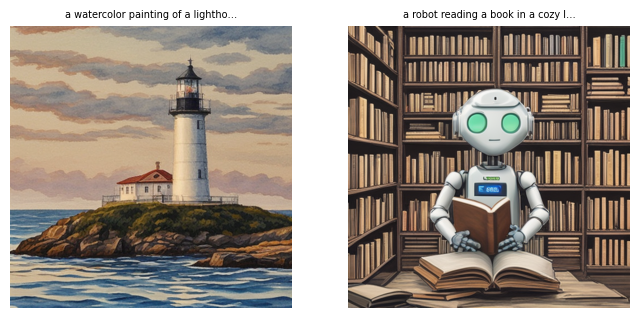

In [3]:
import matplotlib.pyplot as plt

PROMPTS = [
    "a watercolor painting of a lighthouse at dawn",
    "a robot reading a book in a cozy library",
]
gen = torch.Generator(device).manual_seed(42)
fig, axes = plt.subplots(1, len(PROMPTS),
                         figsize=(8, 4))
for ax, p in zip(axes, PROMPTS):
    img = pipe(p, num_inference_steps=2,
               guidance_scale=0.0,
               generator=gen).images[0]
    ax.imshow(img)
    ax.set_title(p[:34] + "…", fontsize=7)
    ax.axis("off")
plt.show()

같은 시드·같은 프롬프트면 같은 그림이 나온다 — 생성도 결국 결정적 계산이다. 프롬프트를 바꿔 보자.

### [보조 3] 역방향 과정 엿보기 — 노이즈에서 그림으로

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53597 (\N{HANGUL SYLLABLE TEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


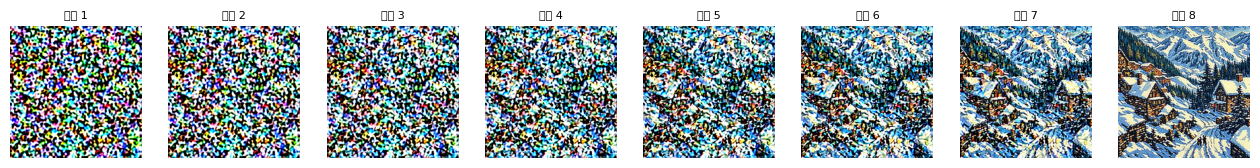

In [4]:
import numpy as np

# 스텝 수를 늘려 중간 이미지를 기록한다
frames = []

def grab(pipe, step, timestep, kw):
    latents = kw["latents"]
    with torch.no_grad():
        img = pipe.vae.decode(
            latents / pipe.vae.config.scaling_factor
        ).sample[0]
    img = ((img / 2 + 0.5).clamp(0, 1)
           .cpu().permute(1, 2, 0).float().numpy())
    frames.append((step, img))
    return kw

gen = torch.Generator(device).manual_seed(7)
_ = pipe("a snowy mountain village, oil painting",
         num_inference_steps=8, guidance_scale=0.0,
         generator=gen,
         callback_on_step_end=grab,
         callback_on_step_end_tensor_inputs=["latents"])

fig, axes = plt.subplots(1, len(frames),
                         figsize=(2 * len(frames), 2.2))
for ax, (s, f) in zip(axes, frames):
    ax.imshow(f)
    ax.set_title(f"스텝 {s + 1}", fontsize=8)
    ax.axis("off")
plt.show()
# 순수 노이즈 → 형태 등장 → 세부 완성:
# 본문 10.5.4 과정 도해와 같은 구도다

### [심화 1] 변형 실험과 오남용 주의

In [5]:
# TODO: 스텝 수(2/8/25)·시드·프롬프트를 바꿔 가며
#       품질과 생성 시간의 트레이드오프를 기록하자.

# ⚠️ 생성 모델 윤리(14장 예고):
# 실존 인물 이미지 생성, 딥페이크 제작은 하지 않는다.
# 생성물 공유 시 AI 생성임을 밝히는 것이 원칙이다.
print("변형 실험은 위 셀들을 복사해 진행하세요.")

변형 실험은 위 셀들을 복사해 진행하세요.


---
## 마무리

- 확산 모델은 "노이즈 제거를 배운 모델"이다 — 역방향 과정을 [보조 3]에서 직접 봤다.
- 스텝 수가 품질-속도 손잡이다 — sd-turbo처럼 스텝을 극단적으로 줄인 증류 모델이 실용화의 열쇠였다(집필 시점 기준).
- 강력함에는 책임이 따른다 — 딥페이크·저작권 논쟁은 14장에서 정면으로 다룬다.